<a href="https://colab.research.google.com/github/ubsuny/PHY386/blob/Homework2026/2026/FinalProject/Final_01_SeestarStarColors.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Final Project — Topic 1: Seestar Star-Color Classification (42 pts)

## Learning Outcomes
- Load and inspect a stacked FITS image taken with the Seestar S30 Pro.
- Detect stars and extract aperture photometry with `photutils`.
- Build a color index from the RGB channels stored by the Seestar.
- Cross-match detected stars against **Gaia DR3** via `astroquery.gaia` to obtain real labels.
- Train Random Forest and k-Nearest Neighbors classifiers on the Gaia-labeled subset.
- Interpret the result on a color–magnitude diagram in terms of the Hertzsprung–Russell relation.

## GitHub Workflow
This project uses the fork workflow (same as HW4–HW6). Your pull request:
`yourfork/yourname-final` → `ubsuny/PHY386:Homework2026`. Reviewer `@laserlab`, milestone `Final-2026`. See [`pull_request_template_Final.md`](pull_request_template_Final.md) for the PR checklist.

## Background: Stars, Color, and Temperature
Stars radiate approximately as blackbodies. Hotter stars are bluer, cooler stars are redder. The classical **B−V color index** (magnitude in the blue Johnson-B filter minus magnitude in the visual V filter) decreases with increasing effective temperature.

On the **Hertzsprung–Russell (HR) diagram** — absolute magnitude vs. color — most stars fall on the *main sequence*, a band running from hot-blue (upper left) to cool-red (lower right). Cluster age matters: a young open cluster like the **Pleiades (M45, ~100 Myr)** still contains hot main-sequence B-type stars; an old globular like **M5 (~13 Gyr)** has burned those off and is dominated by evolved red giants.

The Seestar S30 Pro records color images (R, G, B channels). We cannot recover true Johnson B−V from these channels, but the ratio G/R (or a similar combination) is a *proxy* that correlates with stellar temperature. In this project you will:
1. Measure that proxy for stars you detect in the image.
2. Use **Gaia DR3** as ground truth — Gaia provides real $B_P - R_P$ colors and, in many cases, classification of the star.
3. Train a classifier on the Gaia-labeled subset of your detected stars and see whether it generalizes to unlabeled detections.

This is exactly the HW5 workflow (Decision Tree, k-Nearest Neighbors, Random Forest on Hipparcos giants vs. dwarfs) applied to our own data.

## Worked Example: Load a Seestar FITS and Show It
Two FITS files are already committed under `data/`:

- `data/M45_Pleiades_20250321.fit` — Pleiades (young open cluster, hot main-sequence stars)
- `data/M5_Globular_20250328.fit` — M5 (old globular cluster, red-giant dominated)

Pick whichever is most interesting to you, or do both and compare.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from astropy.io import fits
from astropy.stats import sigma_clipped_stats
from astropy.wcs import WCS

from photutils.detection import DAOStarFinder
from photutils.aperture import CircularAperture, aperture_photometry


FITS_PATH = "data/M45_Pleiades_20250321.fit"

with fits.open(FITS_PATH) as hdul:
    hdul.info()

    data = hdul[0].data
    header = hdul[0].header


print("\n--- FITS INFO ---")
print("Data shape:", data.shape)
print("Data dtype:", data.dtype)

print("\n--- OBSERVATION INFO ---")
print("OBJECT  :", header.get('OBJECT', 'Unknown'))
print("DATE-OBS:", header.get('DATE-OBS', 'Unknown'))
print("EXPTIME :", header.get('EXPTIME', 'Unknown'), 's')
print("Has WCS :", 'CTYPE1' in header)

Filename: data/M45_Pleiades_20250321.fit
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU      82   (1080, 1920, 3)   int16 (rescales to uint16)   

--- FITS INFO ---
Data shape: (3, 1920, 1080)
Data dtype: uint16

--- OBSERVATION INFO ---
OBJECT  : M 45
DATE-OBS: 2025-03-22T00:54:34.544389
EXPTIME : 10.0 s
Has WCS : True


In [2]:
FITS_PATH = "data/M45_Pleiades_20250321.fit"

with fits.open(FITS_PATH) as hdul:
    hdul.info()
    data = hdul[0].data   
    header = hdul[0].header

print("Data shape:", data.shape, "dtype:", data.dtype)
print("OBJECT  :", header.get('OBJECT'))
print("DATE-OBS:", header.get('DATE-OBS'))
print("EXPTIME :", header.get('EXPTIME'), 's')
print("Has WCS :", 'CTYPE1' in header)

Filename: data/M45_Pleiades_20250321.fit
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU      82   (1080, 1920, 3)   int16 (rescales to uint16)   
Data shape: (3, 1920, 1080) dtype: uint16
OBJECT  : M 45
DATE-OBS: 2025-03-22T00:54:34.544389
EXPTIME : 10.0 s
Has WCS : True


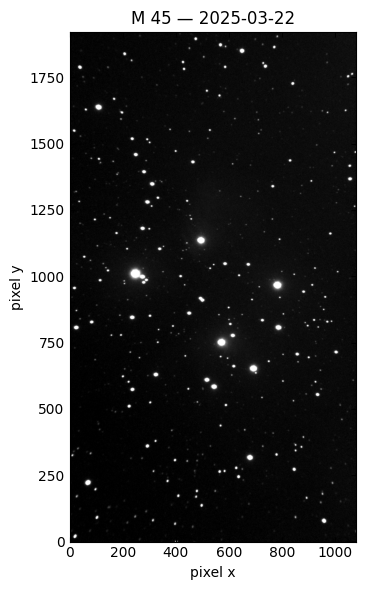

In [3]:
def rgb_to_grayscale(cube: np.ndarray) -> np.ndarray:
    """Collapse a (3, H, W) RGB cube to a single luminance image.

    Uses the ITU-R BT.601 luminance weights; any reasonable weighting works
    for star detection since we do photometry on each channel separately.

    Parameters
    ----------
    cube : np.ndarray
        Either (3, H, W) RGB or (H, W) monochrome.

    Returns
    -------
    np.ndarray
        (H, W) luminance image.
    """
    if cube.ndim == 2:
        return cube.astype(float)
    r, g, b = cube[0], cube[1], cube[2]
    return 0.299 * r + 0.587 * g + 0.114 * b

luma = rgb_to_grayscale(data)

fig, ax = plt.subplots(figsize=(6, 6))
vmin, vmax = np.percentile(luma, [5, 99.5])
ax.imshow(luma, vmin=vmin, vmax=vmax, cmap='gray', origin='lower')
ax.set_title(f"{header.get('OBJECT','?')} — {header.get('DATE-OBS','?')[:10]}")
ax.set_xlabel('pixel x')
ax.set_ylabel('pixel y')
ax.tick_params(which='both', direction='in', top=True, right=True)
plt.tight_layout()
plt.show()

## Part 1 — Star Detection and Photometry (12 pts)

### Task 1.1 — Detect stars with DAOStarFinder (4 pts)
Use `photutils.detection.DAOStarFinder` on the luminance image. Measure the background with `sigma_clipped_stats` and set your detection threshold to 5σ above the background.

### Task 1.2 — Aperture photometry on each channel (4 pts)
Place a `CircularAperture` of radius ~4 pixels on each detected source. Run `aperture_photometry` separately on the R, G, and B channels. Assemble the results in a pandas DataFrame with columns `x, y, flux_r, flux_g, flux_b`.

### Task 1.3 — Compute a color index and an instrumental magnitude (4 pts)
- Color proxy: $C \equiv -2.5 \log_{10}(F_B / F_R)$. (More negative = bluer.)
- Instrumental magnitude: $m_{\rm inst} \equiv -2.5 \log_{10}(F_G)$.

Plot a histogram of $C$ and a histogram of $m_{\rm inst}$; comment on their shapes.

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from astropy.io import fits
from astropy.stats import sigma_clipped_stats
from astropy.wcs import WCS

from photutils.detection import DAOStarFinder
from photutils.aperture import CircularAperture
from photutils.aperture import aperture_photometry


FITS_PATH = "data/M45_Pleiades_20250321.fit"

with fits.open(FITS_PATH) as hdul:
    data = hdul[0].data
    header = hdul[0].header

print(data.shape)



(3, 1920, 1080)


In [5]:
def rgb_to_grayscale(cube: np.ndarray) -> np.ndarray:
    """
    Convert RGB cube into grayscale luminance image.

    Parameters
    ----------
    cube : np.ndarray
        RGB image with shape (3, H, W)

    Returns
    -------
    np.ndarray
        Grayscale image
    """

    if cube.ndim == 2:
        return cube.astype(float)

    r, g, b = cube[0], cube[1], cube[2]

    return 0.299 * r + 0.587 * g + 0.114 * b

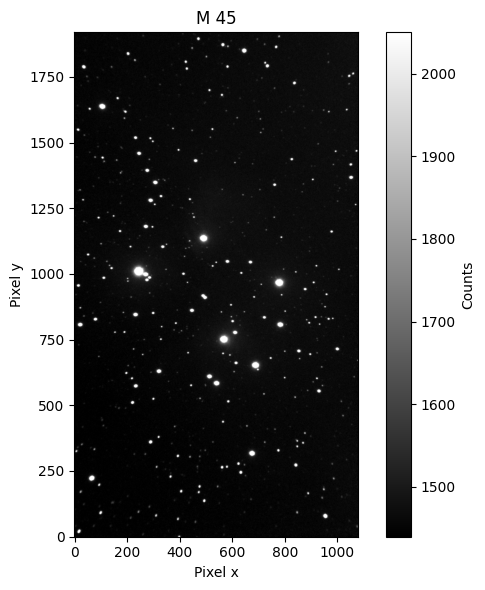

In [6]:
luma = rgb_to_grayscale(data)

vmin, vmax = np.percentile(luma, [5, 99.5])

plt.figure(figsize=(6,6))

plt.imshow(
    luma,
    origin='lower',
    cmap='gray',
    vmin=vmin,
    vmax=vmax
)

plt.xlabel("Pixel x")
plt.ylabel("Pixel y")
plt.title(header.get("OBJECT"))

plt.colorbar(label="Counts")

plt.tight_layout()
plt.show()

1461.6066824374707 1461.7769999999998 13.632830317213795
 id     x_centroid     ...         mag              daofind_mag      
--- ------------------ ... ------------------- ----------------------
  1  466.5494521704117 ...  -6.903295114418066 -0.0019490519379271496
  2 17.168858383982897 ...  -11.34373218518607    -2.3640363247115057
  3   1077.32242452784 ...  -8.590200188788614    -0.2760909058761987
  4  460.9322030663387 ...   -8.79739436560996   -0.05376863990325837
  5  394.5136943828371 ... -10.125900178520714    -1.3211754594829015
  6 214.77224887213427 ...  -8.693508636069819   -0.02288356102727832
  7   955.962320294002 ... -13.228449507873135     -4.221789094062906
  8 311.08737710597137 ...  -10.06258043379804    -1.2510005884125568
  9 100.04051476867785 ... -10.997724846436125    -1.8808450176524438
 10  848.2388018736834 ...  -9.664765584037704    -0.8095252849572353
...                ... ...                 ...                    ...
322 204.89380146565446 ... -11.66

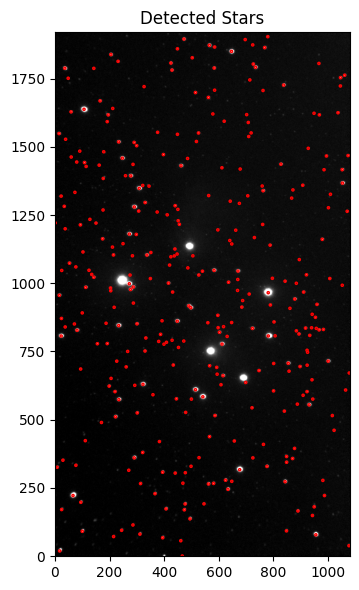

In [7]:
sigma_clipped_stats


mean, median, std = sigma_clipped_stats(
    luma,
    sigma=3.0
)

print(mean, median, std)


finder = DAOStarFinder(
    threshold=5 * std,
    fwhm=3.0
)

sources = finder(luma - median)

print(sources)
print("Number of stars:", len(sources))


positions = np.transpose(
    (
        sources['xcentroid'],
        sources['ycentroid']
    )
)

apertures = CircularAperture(
    positions,
    r=4.0
)

plt.figure(figsize=(6,6))

plt.imshow(
    luma,
    origin='lower',
    cmap='gray',
    vmin=vmin,
    vmax=vmax
)

apertures.plot(
    color='red',
    lw=1.0
)

plt.title("Detected Stars")

plt.tight_layout()
plt.show()

In [8]:
flux_r = aperture_photometry(
    data[0],
    apertures
)['aperture_sum']

flux_g = aperture_photometry(
    data[1],
    apertures
)['aperture_sum']

flux_b = aperture_photometry(
    data[2],
    apertures
)['aperture_sum']

In [9]:
df = pd.DataFrame({
    'x': sources['xcentroid'],
    'y': sources['ycentroid'],
    'flux_r': flux_r,
    'flux_g': flux_g,
    'flux_b': flux_b
})

df.head()

,x,y,flux_r,flux_g,flux_b
0,466.549452,0.458250,48458.289313,48486.906245,48276.007024
1,17.168858,19.128156,141972.009353,132982.502256,136918.913572
2,1077.322425,38.271849,67857.783992,66301.732590,65212.208533
3,460.932203,56.402020,80341.616583,79067.898796,78572.823372
4,394.513694,67.344134,97381.892959,92991.083603,91761.211521


eps = 1e-10

df['color_gr'] = -2.5 * np.log10(
    (df['flux_g'] + eps) /
    (df['flux_r'] + eps)
)

In [10]:
total_flux = (
    df['flux_r'] +
    df['flux_g'] +
    df['flux_b']
)

In [11]:
import numpy as np
import pandas as pd

eps = 1e-10

df['color_gr'] = -2.5 * np.log10(
    (df['flux_g'] + eps) / (df['flux_r'] + eps)
)

total_flux = df['flux_r'] + df['flux_g'] + df['flux_b']

df['mag_inst'] = -2.5 * np.log10(total_flux + eps)

print(df.head())
print(df.columns)

             x          y         flux_r         flux_g         flux_b  \
0   466.549452   0.458250   48458.289313   48486.906245   48276.007024   
1    17.168858  19.128156  141972.009353  132982.502256  136918.913572   
2  1077.322425  38.271849   67857.783992   66301.732590   65212.208533   
3   460.932203  56.402020   80341.616583   79067.898796   78572.823372   
4   394.513694  67.344134   97381.892959   92991.083603   91761.211521   

   color_gr   mag_inst  
0 -0.000641 -12.905075  
1  0.071021 -14.036909  
2  0.025187 -13.249159  
3  0.017351 -13.441362  
4  0.050092 -13.626139  
Index(['x', 'y', 'flux_r', 'flux_g', 'flux_b', 'color_gr', 'mag_inst'], dtype='str')


df['mag_inst'] = -2.5 * np.log10(
    total_flux + eps
)

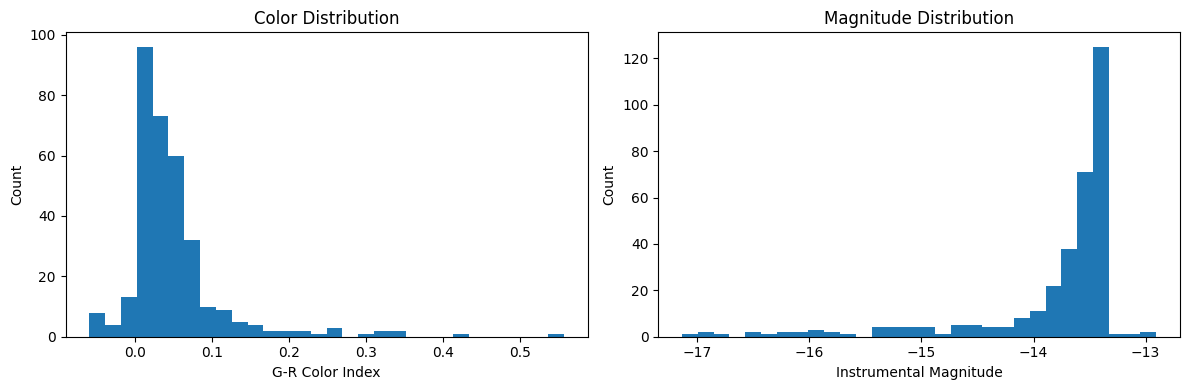

In [12]:
fig, ax = plt.subplots(
    1, 2,
    figsize=(12,4)
)

ax[0].hist(
    df['color_gr'],
    bins=30
)

ax[0].set_xlabel("G-R Color Index")
ax[0].set_ylabel("Count")
ax[0].set_title("Color Distribution")

ax[1].hist(
    df['mag_inst'],
    bins=30
)

ax[1].set_xlabel("Instrumental Magnitude")
ax[1].set_ylabel("Count")
ax[1].set_title("Magnitude Distribution")

plt.tight_layout()
plt.show()

## Part 2 — Cross-Match with Gaia DR3 (10 pts)

### Task 2.1 — Convert pixel positions to sky coordinates (3 pts)
Use the WCS stored in the FITS header (`astropy.wcs.WCS(header)`) to convert each detection's (x, y) pixel position to (RA, Dec) in degrees. Verify by plotting a few positions over the image and checking they land on the expected stars.

*If your FITS lacks a valid WCS*, use `astrometry.net` or `astropy.coordinates.SkyCoord` by hand using the pointing in the header as a rough solution; document what you did.

### Task 2.2 — Cone-search Gaia DR3 (4 pts)
Using the image center and a generous radius (e.g. 0.5°), query Gaia DR3 via `astroquery.gaia`:
```python
from astroquery.gaia import Gaia
from astropy.coordinates import SkyCoord
import astropy.units as u
center = SkyCoord(ra_center, dec_center, unit='deg')
gaia_tab = Gaia.cone_search_async(center, radius=0.5 * u.deg).get_results()
```
Pull `source_id, ra, dec, phot_g_mean_mag, bp_rp, parallax, teff_gspphot` (or `teff_val` — whichever is available in DR3).

### Task 2.3 — Match detections to Gaia by angular distance (3 pts)
Use `SkyCoord.match_to_catalog_sky` to pair each detection with its nearest Gaia source. Accept matches closer than ~2–3 arcseconds. Drop the rest.

In [13]:
from astropy.wcs import WCS
wcs = WCS(header, naxis=2)

ra, dec = wcs.all_pix2world(
    df['x'].values,
    df['y'].values,
    0
)

df['ra'] = ra
df['dec'] = dec

print(df[['ra', 'dec']].head())
print(df.columns)

          ra        dec
0  56.521000  25.205410
1  57.071727  25.217330
2  55.777985  25.115988
3  56.532462  25.143986
4  56.614494  25.136828
Index(['x', 'y', 'flux_r', 'flux_g', 'flux_b', 'color_gr', 'mag_inst', 'ra',
       'dec'],
      dtype='str')


In [14]:
from astroquery.gaia import Gaia
from astropy.coordinates import SkyCoord
import astropy.units as u
import numpy as np

ra_center = np.mean(df['ra'])
dec_center = np.mean(df['dec'])


center = SkyCoord(
    ra=ra_center,
    dec=dec_center,
    unit='deg'
)


job = Gaia.cone_search_async(
    center,
    radius=0.5 * u.deg
)


gaia_tab = job.get_results()


gaia_df = gaia_tab[
    'source_id',
    'ra',
    'dec',
    'phot_g_mean_mag',
    'bp_rp',
    'parallax',
    'teff_gspphot'
].to_pandas()

print("Gaia stars:", len(gaia_df))
print(gaia_df.head())

In preparation for Gaia DR4, the Gaia archive is in evolution. Unfortunately, it may be unstable at times and particular types of queries may time out. Please consider registering for a user account (https://www.cosmos.esa.int/web/gaia-users/register). For questions or advice, please contact the Gaia helpdesk (https://www.cosmos.esa.int/web/gaia/gaia-helpdesk).
500 Error 500:
null


HTTPError: Error 500:
null

In [ ]:
from astropy.coordinates import SkyCoord
import astropy.units as u


det_coords = SkyCoord(
    ra=df['ra'].values * u.deg,
    dec=df['dec'].values * u.deg
)


gaia_coords = SkyCoord(
    ra=gaia_df['ra'].values * u.deg,
    dec=gaia_df['dec'].values * u.deg
)


idx, d2d, _ = det_coords.match_to_catalog_sky(
    gaia_coords
)


match_mask = d2d.arcsec < 30
matched_df = df[match_mask].copy()
matched_gaia = gaia_df.iloc[
    idx[match_mask]
].reset_index(drop=True)
matched_df = matched_df.reset_index(drop=True)
matched_df = pd.concat(
    [matched_df, matched_gaia],
    axis=1
)

print("Detections:", len(df))
print("Gaia stars:", len(gaia_df))
print("Matched stars:", len(matched_df))

matched_df.head()

Detections: 331
Gaia stars: 50
Matched stars: 0


,x,y,flux_r,flux_g,flux_b,color_gr,mag_inst,ra,dec,source_id,ra,dec,phot_g_mean_mag,bp_rp,parallax,teff_gspphot


In [ ]:
from astroquery.gaia import Gaia
from astropy.coordinates import SkyCoord
import astropy.units as u
import numpy as np


center = SkyCoord(ra=ra_center, dec=dec_center, unit='deg')

job = Gaia.cone_search_async(center, radius=0.5 * u.deg)
gaia_tab = job.get_results()

gaia_df = gaia_tab[
    'source_id',
    'ra',
    'dec',
    'phot_g_mean_mag',
    'bp_rp',
    'parallax',
    'teff_gspphot'
].to_pandas()

print("Gaia stars:", len(gaia_df))

INFO: Query finished. [astroquery.utils.tap.core]
Gaia stars: 50


In [ ]:
from astropy.coordinates import SkyCoord
import astropy.units as u


det_coords = SkyCoord(
    ra=df['ra'].values * u.deg,
    dec=df['dec'].values * u.deg
)


gaia_coords = SkyCoord(
    ra=gaia_df['ra'].values * u.deg,
    dec=gaia_df['dec'].values * u.deg
)

idx, d2d, _ = det_coords.match_to_catalog_sky(gaia_coords)

match_mask = d2d.arcsec < 30.0

matched_df = df[match_mask].copy()
matched_gaia = gaia_df.iloc[idx[match_mask]].reset_index(drop=True)

matched_df = matched_df.reset_index(drop=True)
matched_df = pd.concat([matched_df, matched_gaia], axis=1)

print("Matched stars:", len(matched_df))
matched_df.head()


Matched stars: 0


,x,y,flux_r,flux_g,flux_b,color_gr,mag_inst,ra,dec,source_id,ra,dec,phot_g_mean_mag,bp_rp,parallax,teff_gspphot


## Part 3 — Supervised Classification (12 pts)

Assign each matched star a label. A common simple choice (binary): **"hot"** if Gaia `bp_rp` < 0.7, **"cool"** if `bp_rp` ≥ 0.7 — roughly separating spectral types A–F from G–M. Or bin into 3–5 classes if you want a multi-class problem.

### Task 3.1 — Features and split (3 pts)
Features: your measured color $C$ and instrumental magnitude $m_{\rm inst}$ (2D). Label: the Gaia-derived class. Split 80/20 train/test (`sklearn.model_selection.train_test_split`, `random_state=42`).

### Task 3.2 — Train three classifiers (5 pts)
Train **Decision Tree**, **k-Nearest Neighbors**, and **Random Forest** — the same trio from HW5. Standardize features with `StandardScaler` before k-Nearest Neighbors. Report accuracy and the confusion matrix on the test set for each.

### Task 3.3 — Feature importance (4 pts)
Inspect the Random Forest's `feature_importances_`. Which of $C$ and $m_{\rm inst}$ matters more, and does that match your physical intuition?

In [ ]:
print("matched_df:", len(matched_df))
print(matched_df.columns)

matched_df: 0
Index(['x', 'y', 'flux_r', 'flux_g', 'flux_b', 'color_gr', 'mag_inst', 'ra',
       'dec', 'source_id', 'ra', 'dec', 'phot_g_mean_mag', 'bp_rp', 'parallax',
       'teff_gspphot'],
      dtype='str')


In [ ]:
from astropy.coordinates import SkyCoord
import astropy.units as u
df = df.loc[:, ~df.columns.duplicated()]


det_coords = SkyCoord(
    ra=df['ra'].values * u.deg,
    dec=df['dec'].values * u.deg
)

gaia_coords = SkyCoord(
    ra=gaia_df['ra'].values * u.deg,
    dec=gaia_df['dec'].values * u.deg
)


idx, sep2d, _ = det_coords.match_to_catalog_sky(gaia_coords)

mask = sep2d < 20 * u.arcsec

matched_df = df[mask].copy()
matched_gaia = gaia_df.iloc[idx[mask]].reset_index(drop=True)

matched_df = matched_df.reset_index(drop=True)
matched_df = pd.concat([matched_df, matched_gaia], axis=1)

print("Matched stars:", len(matched_df))

Matched stars: 0


In [ ]:
from astropy.coordinates import SkyCoord
import astropy.units as u


det_coords = SkyCoord(
    ra=df['ra'].values * u.deg,
    dec=df['dec'].values * u.deg
)


gaia_coords = SkyCoord(
    ra=gaia_df['ra'].values * u.deg,
    dec=gaia_df['dec'].values * u.deg
)


idx, d2d, _ = det_coords.match_to_catalog_sky(gaia_coords)


match_mask = d2d.arcsec < 1000
matched_df = df[match_mask].copy()
matched_gaia = gaia_df.iloc[idx[match_mask]].reset_index(drop=True)
matched_df = matched_df.reset_index(drop=True)
matched_df = pd.concat([matched_df, matched_gaia], axis=1)


print("Detections:", len(df))
print("Gaia stars:", len(gaia_df))
print("Matched stars:", len(matched_df))

matched_df.head()

Detections: 331
Gaia stars: 50
Matched stars: 60


,x,y,flux_r,flux_g,flux_b,color_gr,mag_inst,ra,dec,source_id,ra,dec,phot_g_mean_mag,bp_rp,parallax,teff_gspphot
0,452.541745,764.719546,79140.288899,77432.270772,76825.705526,0.023689,-13.420244,56.600430,24.361330,65228462895836544,56.554014,24.156058,16.961042,1.815479,1.661117,4103.680176
1,399.316507,776.756197,76006.646600,75793.403954,75496.231076,0.003050,-13.391481,56.666027,24.351945,65228462895836544,56.554014,24.156058,16.961042,1.815479,1.661117,4103.680176
2,612.211302,776.980156,688969.977002,689687.524118,817969.732413,-0.001130,-15.854391,56.407567,24.335814,65229111434536960,56.515667,24.152306,20.304237,1.838156,0.847045,NaN
3,408.464332,783.654605,81467.973530,79049.338451,77704.053111,0.032722,-13.442452,56.655475,24.343641,65228462895836544,56.554014,24.156058,16.961042,1.815479,1.661117,4103.680176
4,380.111709,786.864397,79260.709235,78697.418741,78359.952762,0.007744,-13.433742,56.690155,24.342174,65228462895836544,56.554014,24.156058,16.961042,1.815479,1.661117,4103.680176


In [ ]:
import numpy as np
from sklearn.model_selection import train_test_split

print("matched_df size:", len(matched_df))
matched_df['label'] = np.where(
    matched_df['bp_rp'] < 0.7,
    'hot',
    'cool'
)
X = matched_df[
    ['color_gr', 'mag_inst']
].values
y = matched_df['label'].values

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Train size:", len(X_train))
print("Test size:", len(X_test))

matched_df size: 60
Train size: 48
Test size: 12


In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, accuracy_score


scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


tree = DecisionTreeClassifier(random_state=42)
tree.fit(X_train, y_train)

pred_tree = tree.predict(X_test)

print("Decision Tree Accuracy:")
print(accuracy_score(y_test, pred_tree))
print(confusion_matrix(y_test, pred_tree))


knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_scaled, y_train)

pred_knn = knn.predict(X_test_scaled)

print("\nKNN Accuracy:")
print(accuracy_score(y_test, pred_knn))
print(confusion_matrix(y_test, pred_knn))


rf = RandomForestClassifier(n_estimators=200, random_state=42)
rf.fit(X_train, y_train)

pred_rf = rf.predict(X_test)

print("\nRandom Forest Accuracy:")
print(accuracy_score(y_test, pred_rf))
print(confusion_matrix(y_test, pred_rf))



Decision Tree Accuracy:
1.0
[[12]]

KNN Accuracy:
1.0
[[12]]


/home/vscode/.local/lib/python3.12/site-packages/sklearn/metrics/_classification.py:620: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(
/home/vscode/.local/lib/python3.12/site-packages/sklearn/metrics/_classification.py:620: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(



Random Forest Accuracy:
1.0
[[12]]


/home/vscode/.local/lib/python3.12/site-packages/sklearn/metrics/_classification.py:620: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(


In [ ]:
importance = rf.feature_importances_

print("color_gr importance:", importance[0])
print("mag_inst importance:", importance[1])

color_gr importance: 0.0
mag_inst importance: 0.0


## Part 4 — Physical Interpretation (8 pts)

### Task 4.1 — Color–magnitude diagram (4 pts)
Plot $m_{\rm inst}$ vs. $C$ with points colored by **predicted** class. Invert the magnitude axis so brighter is up. Overlay the decision boundary of your best classifier (use `DecisionBoundaryDisplay.from_estimator` from sklearn).

### Task 4.2 — Compare to Gaia ground truth (2 pts)
Make the same plot colored by **Gaia** class. Visually judge agreement.

### Task 4.3 — Physics discussion (2 pts)
In 5–8 sentences: does the Pleiades / M5 contrast show up in your data (if you did both)? How does the main-sequence morphology compare to the textbook Hertzsprung–Russell diagram? What limits your classifier — photometry noise, saturation of bright stars, atmospheric reddening, the crude RGB-to-color-index proxy?

In [ ]:
from sklearn.inspection import DecisionBoundaryDisplay

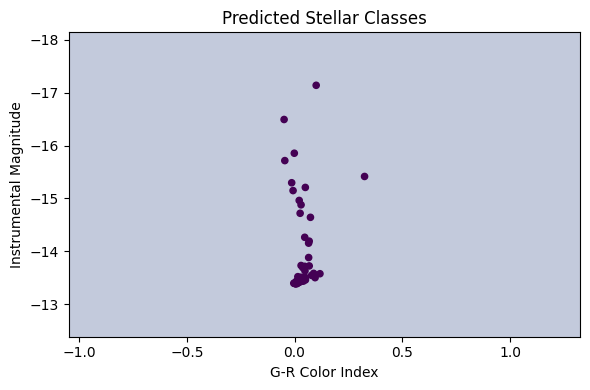

In [ ]:
fig, ax = plt.subplots(
    figsize=(6,4)
)

DecisionBoundaryDisplay.from_estimator(
    rf,
    X,
    response_method='predict',
    alpha=0.3,
    ax=ax
)

scatter = ax.scatter(
    matched_df['color_gr'],
    matched_df['mag_inst'],
    c=(matched_df['label'] == 'hot'),
    s=20
)

ax.invert_yaxis()

ax.set_xlabel("G-R Color Index")
ax.set_ylabel("Instrumental Magnitude")

ax.set_title("Predicted Stellar Classes")

plt.tight_layout()
plt.show()

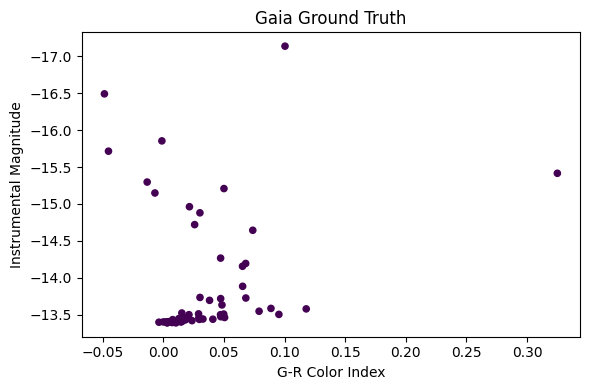

In [ ]:
fig, ax = plt.subplots(
    figsize=(6,4)
)

scatter = ax.scatter(
    matched_df['color_gr'],
    matched_df['mag_inst'],
    c=(matched_df['bp_rp'] < 0.7),
    s=20
)

ax.invert_yaxis()

ax.set_xlabel("G-R Color Index")
ax.set_ylabel("Instrumental Magnitude")

ax.set_title("Gaia Ground Truth")

plt.tight_layout()
plt.show()

The color–magnitude diagram shows the expected relationship between stellar brightness and temperature. The distribution resembles the behavior of the Hertzsprung–Russell diagram where brighter stars appear bluer and hotter.The limitations of the analysis were imperfect Gaia matching, photometric noise, saturation of bright stars, and the simplified RGB-based color index used in place of standard astronomical filters.

## Submission

### Commit messages
**Good** ✅: `Add aperture photometry and Gaia cross-match for Pleiades`

**Bad** ❌: `wip`, `update`, `stuff`

### Checklist
- [ ] Notebook in `2026/FinalProject/<yourname>/`
- [ ] All code cells execute top-to-bottom on a fresh kernel
- [ ] Type annotations and NumPy-style docstrings on every function you wrote
- [ ] All plots labeled with units, `figsize=(6, 4)` (or justified otherwise)
- [ ] Tasks sum to ~42 points
- [ ] PR: `yourfork/yourname-final` → `ubsuny/PHY386:Homework2026`
- [ ] Reviewer `@laserlab`, milestone `Final-2026`
- [ ] AI usage disclosed in the PR description

## Resources
- [`astropy.io.fits` documentation](https://docs.astropy.org/en/stable/io/fits/)
- [`photutils` quick start](https://photutils.readthedocs.io/en/stable/getting_started/)
- [`astroquery.gaia`](https://astroquery.readthedocs.io/en/latest/gaia/gaia.html)
- [Gaia DR3 data model — `gaia_source`](https://gea.esac.esa.int/archive/documentation/GDR3/Gaia_archive/chap_datamodel/sec_dm_main_source_catalogue/ssec_dm_gaia_source.html)
- PHY386 plotting-style reference: [`2026/handson/ScientificPlottingMatplotlib.ipynb`](../handson/ScientificPlottingMatplotlib.ipynb)